# CIFAR10 Image Classification using CNN (PyTorch)

This project builds a Convolutional Neural Network to classify images from the CIFAR10 dataset.

Framework: PyTorch  
Task: Image Classification  
Classes: 10 object categories

In [1]:
import torch 
import torch.nn as nn
import torch.optim as optim

In [2]:
import torchvision
from torchvision.datasets import CIFAR10

In [3]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [4]:
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

trainset=CIFAR10(root="./data",download=True,transform=transform,train=True)
testset=CIFAR10(root="./data",download=True,transform=transform,train=False)

In [5]:
train_loader=DataLoader(trainset,batch_size=64,shuffle=True)
test_loader=DataLoader(testset,batch_size=64)

In [6]:
# Build the model

class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()

        self.conv_layer=nn.Sequential(
             nn.Conv2d(3,32,kernel_size=3,padding=1),
             nn.ReLU(),   
             nn.MaxPool2d(2,2),
    
             nn.Conv2d(32,64,kernel_size=3,padding=1),
             nn.ReLU(),   
             nn.MaxPool2d(2,2),
    
    
             nn.Conv2d(64,128,kernel_size=3,padding=1),
             nn.ReLU(),   
             nn.MaxPool2d(2,2),
            
        )

        self.fc_layer=nn.Sequential(
            nn.Linear(2048,256),
            nn.ReLU(),

            nn.Linear(256,10)
        )
    
    def forward(self,x):
        feature_map=self.conv_layer(x)
        flatten=feature_map.view(feature_map.size(0),-1)
        op= self.fc_layer(flatten)

        return op

In [7]:
model=CNN()

criteria=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters())

In [8]:
#train the model

epochs=10

train_losses=[]
test_losses=[]
best_loss=float("inf")
best_epoch=0

for epoch in range(epochs):
        model.train()
        epoch_train_loss=0
    
        for xb,yb in train_loader:
            optimizer.zero_grad()
            output=model(xb)
            loss=criteria(output,yb)
            loss.backward()
            optimizer.step() # weight updation
            
            epoch_train_loss+=loss.item()  # For 1 batch loss 
        
             
        avg_loss_epoch=epoch_train_loss/len(train_loader) # avg loss per epoch
                
        train_losses.append(avg_loss_epoch)
        
        
        # Validation
        model.eval()
        epoch_test_loss=0
        with torch.no_grad():
            for xb,yb in test_loader:
                    pred=model(xb)
                    loss=criteria(pred,yb)
                    epoch_test_loss+=loss.item()
        
        avg_valid_loss=epoch_test_loss/len(test_loader)
        
        test_losses.append(avg_valid_loss)
        
        print(f"for {epoch+1}/{epochs} training loss:{avg_loss_epoch} & validation loss:{avg_valid_loss}")

        
        if avg_valid_loss < best_loss:
           best_loss=avg_valid_loss
           best_epoch=epoch+1
           torch.save(model.state_dict(),"best CIFAR10 model.pt")
print(f"Best_model for {best_epoch} having val_loss{best_loss}"     

for 1/10 training loss:1.3688744896513116 & validation loss:1.0686718669666606
for 2/10 training loss:0.93034850377256 & validation loss:0.854142795322807
for 3/10 training loss:0.7559103492047171 & validation loss:0.7860832322554984
for 4/10 training loss:0.6235979879679887 & validation loss:0.7490734588948025
for 5/10 training loss:0.5136548285479741 & validation loss:0.7432390124934494
for 6/10 training loss:0.41701260797889034 & validation loss:0.7683328974778485
for 7/10 training loss:0.3243299464568915 & validation loss:0.8555292601038695
for 8/10 training loss:0.2471877987332204 & validation loss:0.9312222909395862
for 9/10 training loss:0.18936092721398376 & validation loss:1.08731630102844
for 10/10 training loss:0.14575881882549246 & validation loss:1.0873788473712411


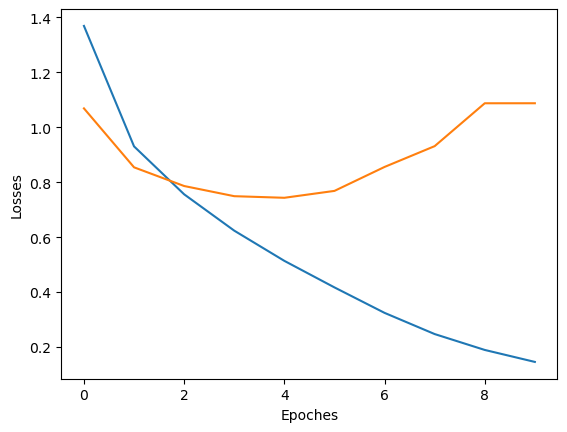

In [9]:
import matplotlib.pyplot as plt

plt.plot(range(epochs),train_losses,label="Train_losses")
plt.plot(range(epochs),test_losses,label="Test_losses")


plt.xlabel("Epoches")
plt.ylabel("Losses")

plt.show()

In [10]:
# load the best model

model.load_state_dict(torch.load("best CIFAR10 model.pt"))

In [16]:
model.eval()
correct_pred=0
total_samples=0
with torch.no_grad():
    for images,labels in test_loader:
        op=model(images)
        _,pred=torch.max(op,1)
        correct_pred+=(pred==labels).sum().item()
        total_samples+=labels.size(0)

    print(f"Accuracy:{(correct_pred/total_samples)*100}")

accuracy:75.13
